In [1]:
import pandas as pd

df = pd.read_csv('Online Retail.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.info())
print(df.isna().sum().sort_values(ascending=False).head(15))

(541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Co

In [2]:
for col in df.columns:
    print(col, df[col].head(3).tolist())

InvoiceNo ['536365', '536365', '536365']
StockCode ['85123A', '71053', '84406B']
Description ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER']
Quantity [6, 6, 8]
InvoiceDate ['12/1/10 8:26', '12/1/10 8:26', '12/1/10 8:26']
UnitPrice [2.55, 3.39, 2.75]
CustomerID [17850.0, 17850.0, 17850.0]
Country ['United Kingdom', 'United Kingdom', 'United Kingdom']


In [3]:
#CLEANING DATA

# Copy dataframe
df_clean = df.copy()

#Drop missing CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

#Convert CustomerID to int
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

#Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

#Remove cancellations (InvoiceNo starts with 'C')
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")]

#Remove negative or zero quantity
df_clean = df_clean[df_clean["Quantity"] > 0]

#Remove zero or negative price (just in case)
df_clean = df_clean[df_clean["UnitPrice"] > 0]

#Create TotalPrice column
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print(df_clean.shape)
print(df_clean.head())

/var/folders/b1/qsd2jkwj3fx29gxkk2b1plmr0000gn/T/ipykernel_45961/2974313340.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])


(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  


In [5]:
print(df_clean.describe())
print(df_clean["CustomerID"].nunique())

            Quantity                 InvoiceDate      UnitPrice  \
count  397884.000000                      397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023       3.116488   
min         1.000000         2010-12-01 08:26:00       0.001000   
25%         2.000000         2011-04-07 11:12:00       1.250000   
50%         6.000000         2011-07-31 14:39:00       1.950000   
75%        12.000000         2011-10-20 14:33:00       3.750000   
max     80995.000000         2011-12-09 12:50:00    8142.750000   
std       179.331775                         NaN      22.097877   

          CustomerID     TotalPrice  
count  397884.000000  397884.000000  
mean    15294.423453      22.397000  
min     12346.000000       0.001000  
25%     13969.000000       4.680000  
50%     15159.000000      11.800000  
75%     16795.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.141560     309.071041  
4338


In [6]:
#building RFM features
#recency -> how recently a customer purchased
#frequency -> how often they purchase
#monetary -> how much they spend

#Reference date (important for recency)
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

#RFM features
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency
    "TotalPrice": "sum"                                       # Monetary
})

#Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

#Reset index
rfm = rfm.reset_index()

# Show results
print(rfm.head())
print(rfm.describe())

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


In [7]:
rfm.describe()
#recency (mean ~92 days) -> many customers haven't purchased recently -> churn potential
#frequency (median = 2) -> most customers dont buy often (common in retail)
#monetary (max = 280k) -> a few very high-value customers dominate revenue

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [8]:
#handling skew
#clustering won't work well yet b/c monetary is extremely skewed, KMeans is distanced based (outliers
#dominate)

#log transformation + scaling 
#log transform -> reduces skew and outlier impact
#scaling -> ensures all features contribute equally
#without these clustering would be meaningless

import numpy as np
from sklearn.preprocessing import StandardScaler

#Log transform (to reduce skew)
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

#Scale features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

#Convert back to DataFrame
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

#Preview
print(rfm_scaled.head())
print(rfm_scaled.describe())

    Recency  Frequency  Monetary
0  1.461993  -0.955214  3.706225
1 -2.038734   1.074425  1.411843
2  0.373104   0.386304  0.716489
3 -0.623086  -0.955214  0.698739
4  1.424558  -0.955214 -0.618962
            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean  -8.025955e-17 -8.189750e-18  2.817274e-16
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -2.341296e+00 -9.552143e-01 -4.004574e+00
25%   -6.613615e-01 -9.552143e-01 -6.856676e-01
50%    8.992557e-02 -3.615828e-01 -6.218718e-02
75%    8.447915e-01  6.532370e-01  6.541861e-01
max    1.564198e+00  5.858535e+00  4.731591e+00


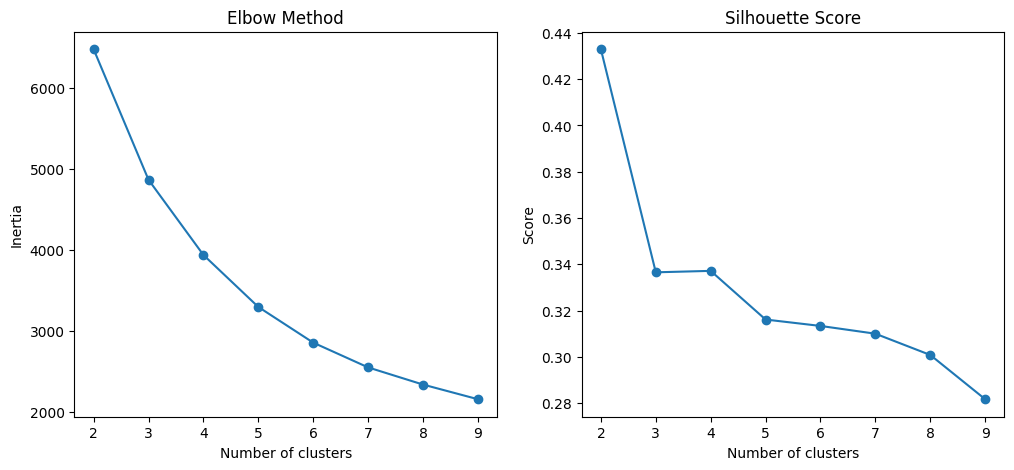

In [9]:
#finding optimal K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Elbow
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

# Silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Score")

plt.show()

In [ ]:
#clustering has 2 goals: 
#1. Mathematical fit: inertia, silhouette
#2. Business usefullness (more important)
#problem w/ k =2: get something like cluster 1-> low-value customers, cluster 2-> high-value customers
#not very actionable
#k = 4-> can get segments like high-value loyal customers, at-risk high-value customers, 
#low-frequency low-value customers, new or occasional customers

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Check distribution
print(rfm["Cluster"].value_counts())

# Preview
rfm.head()

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,1
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,3


In [11]:
rfm.groupby("Cluster").mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15425.540024,18.124253,2.148148,551.819534
1,15192.328212,12.131285,13.713687,8074.266872
2,15211.258312,71.084399,4.083546,1802.829005
3,15348.312655,182.496898,1.318238,343.450032


In [ ]:
#Cluster 1 (best cluster)-> recency low (recent), frequency very high, monetary very high
#Cluster 1 -> high-value loyal customers, buy often, spend a lot, are active
#Cluster 1 -> strategy: loyalty rewards, VIP perks, early access, personalized recommendations
#Cluster 1 -> goal: retain + maximize lifetime value
#Cluster 0-> recency low (recent), frequency low, monetary low-medium
#Cluster 0-> recent low-value customers, just bought recently, haven't built habits yet
#Cluster 0 -> strategy: onboarding emails, first-time discounts, product recommendations
#Cluster 0-> goal: increase frequency + convert to loyal
#Cluster 2-> recency medium high (haven't purchased in a while), frequency medium, monetary medium high
#Cluster 2-> at-risk valuable customers, used to spend, used to buy somewhat often, now drifting away
#Cluster 2-> strategy: targeted discounts, re-engagement campaigns, "we miss you" emails
#Cluster 2-> goal: win them back before churn
#Cluster 3 (worst cluster) -> recency very high (haven't purchases in long time), frequency very low,
#monetary low -> inactive/churned customers
#Cluster 3 -> strategy: low-cost reactivation campagins, possibly ignore (not worth spending much)
#Cluster 3-> goal: cost-efficient targeting

In [12]:
rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
})

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,18.124253,2.148148,551.819534,837
1,12.131285,13.713687,8074.266872,716
2,71.084399,4.083546,1802.829005,1173
3,182.496898,1.318238,343.450032,1612


In [ ]:
#based on above, most customers are low value or inactive (CLuster 3), but most revenue likely comes
#from Cluster 1 (small but high-value). Classic Pareto-type situation

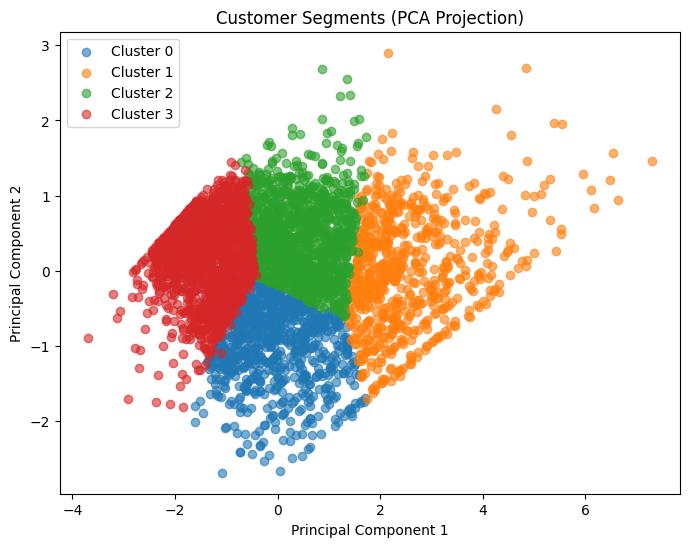

In [13]:
#PCA was used to project the high-dimensional customer feature space into 2 dimensions for visualization.
#Resulting plot shows clear separatiom between clusters, supporting the effectiveness of the segmentation

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create DataFrame
pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = rfm["Cluster"]

# Plot
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA Projection)")
plt.legend()
plt.grid(False)
plt.show()

In [14]:
#cluster names
cluster_names = {
    0: "Recent Low-Value Customers",
    1: "High-Value Loyal Customers",
    2: "At-Risk Valuable Customers",
    3: "Inactive Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,2,At-Risk Valuable Customers
1,12347,2,7,4310.00,1,High-Value Loyal Customers
2,12348,75,4,1797.24,2,At-Risk Valuable Customers
3,12349,19,1,1757.55,0,Recent Low-Value Customers
4,12350,310,1,334.40,3,Inactive Customers


In [16]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


In [17]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,18.124253,2.148148,551.819534
1,12.131285,13.713687,8074.266872
2,71.084399,4.083546,1802.829005
3,182.496898,1.318238,343.450032


In [18]:
rfm.groupby(["Cluster", "Segment"]).size()

Cluster  Segment                   
0        Recent Low-Value Customers     837
1        High-Value Loyal Customers     716
2        At-Risk Valuable Customers    1173
3        Inactive Customers            1612
dtype: int64

In [19]:
#revenue generated per cluster
revenue_by_segment = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

print(revenue_by_segment)

Segment
High-Value Loyal Customers    5781175.080
At-Risk Valuable Customers    2114718.423
Inactive Customers             553641.451
Recent Low-Value Customers     461872.950
Name: Monetary, dtype: float64


In [20]:
#what percent of total revenue generated by each cluster
revenue_pct = revenue_by_segment / revenue_by_segment.sum() * 100
print(revenue_pct)

Segment
High-Value Loyal Customers    64.873869
At-Risk Valuable Customers    23.730464
Inactive Customers             6.212727
Recent Low-Value Customers     5.182940
Name: Monetary, dtype: float64


In [21]:
#small segment of customers drives majority of revenue
#high-value loyal customers represent relatively small portion of customer base but generate nearly 2/3
#of total revenue
#combining segments: high-value + at-risk = ~89% of revenue -> nearly 90% of revenue comes from 
#customers who are either currently high-value or at risk of churn
#if you lose at-risk segment -> lose ~24% of reveue -> massive
#model reveals that nearly 90% of revenue is concentrated among high-value and at-risk customers, 
#highlighting importance of retention strategies for maintaining business performance


revenue_by_segment
revenue_pct

Segment
High-Value Loyal Customers    64.873869
At-Risk Valuable Customers    23.730464
Inactive Customers             6.212727
Recent Low-Value Customers     5.182940
Name: Monetary, dtype: float64

In [22]:
#revenue impact simulation -> what happens if improve retention
#if retention of at-risk customers improves by just 10% business could recover $211,471 in reveue

# Total revenue
total_revenue = rfm["Monetary"].sum()

# At-risk segment revenue
at_risk_revenue = rfm[rfm["Segment"] == "At-Risk Valuable Customers"]["Monetary"].sum()

# Assume we improve retention by 10%
uplift_rate = 0.10

recovered_revenue = at_risk_revenue * uplift_rate

print("Total Revenue:", total_revenue)
print("At-Risk Revenue:", at_risk_revenue)
print("Potential Recovered Revenue (10% improvement):", recovered_revenue)

Total Revenue: 8911407.904
At-Risk Revenue: 2114718.423
Potential Recovered Revenue (10% improvement): 211471.84230000002


In [24]:
#saving dataset to use later for dashboard
# Assuming you already created pca_df earlier and rfm already has Segment
# If pca_df does not have CustomerID yet, add it from rfm in matching order

rfm_dashboard = rfm.copy()
rfm_dashboard["PC1"] = pca_df["PC1"].values
rfm_dashboard["PC2"] = pca_df["PC2"].values

rfm_dashboard.to_csv("rfm_with_segments.csv", index=False)

print(rfm_dashboard.head())

   CustomerID  Recency  Frequency  Monetary  Cluster  \
0       12346      326          1  77183.60        2   
1       12347        2          7   4310.00        1   
2       12348       75          4   1797.24        2   
3       12349       19          1   1757.55        0   
4       12350      310          1    334.40        3   

                      Segment       PC1       PC2  
0  At-Risk Valuable Customers  0.872658  2.686758  
1  High-Value Loyal Customers  2.550260 -0.804427  
2  At-Risk Valuable Customers  0.475142  0.746121  
3  Recent Low-Value Customers  0.145832 -0.460480  
4          Inactive Customers -1.688990  0.676555  


In [36]:
#running streamlit

!streamlit run dashboard.py --server.headless true




  You can now view your Streamlit app in your browser.

  Network URL: http://10.0.0.58:8501
  External URL: http://71.234.15.229:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            

  A new version of Streamlit is available.

  See what's new at https://discuss.streamlit.io/c/announcements

  Enter the following command to upgrade:
  $ pip install streamlit --upgrade

^C
  Stopping...


In [28]:
import os

# Create .streamlit folder if it doesn't exist
os.makedirs(".streamlit", exist_ok=True)

# Create config.toml file
config_text = """
[theme]
primaryColor="#4CAF50"
backgroundColor="#0E1117"
secondaryBackgroundColor="#262730"
textColor="#FFFFFF"
font="sans serif"
"""

with open(".streamlit/config.toml", "w") as f:
    f.write(config_text)

print("Streamlit theme file created!")

Streamlit theme file created!


In [39]:
#saving images for github repo
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create images folder
os.makedirs("images", exist_ok=True)

from sklearn.decomposition import PCA

# Recompute PCA 
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Add to dataframe
rfm["PC1"] = rfm_pca[:, 0]
rfm["PC2"] = rfm_pca[:, 1]

# 1. PCA PLOT
plt.figure(figsize=(8,6))

for segment in rfm["Segment"].unique():
    subset = rfm[rfm["Segment"] == segment]
    plt.scatter(subset["PC1"], subset["PC2"], label=segment, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA Projection)")
plt.legend()
plt.tight_layout()

plt.savefig("images/pca_plot.png", dpi=300)
plt.close()

# 2. CUSTOMER COUNT
segment_counts = rfm["Segment"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(segment_counts.index, segment_counts.values)
plt.ylabel("Customers")
plt.xlabel("Segment")
plt.title("Customer Count by Segment")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig("images/segment_distribution.png", dpi=300)
plt.close()

# 3. REVENUE BY SEGMENT
revenue_by_segment = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(revenue_by_segment.index, revenue_by_segment.values)
plt.ylabel("Revenue ($)")
plt.xlabel("Segment")
plt.title("Revenue Contribution")
plt.xticks(rotation=20, ha="right")

# Format y-axis with dollars
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.savefig("images/revenue_chart.png", dpi=300)
plt.close()

print("Images saved to /images folder!")

Images saved to /images folder!
